# 5.3 Data and Making the Problem Visible

**Part:** 5 — Disease Mapping and Bayesian Smoothing (Chapter 5.3 of 11)

**Dataset:** `diabetes_northeast.shp`; a simulation with known truth on the same county graph; `cancer_areas.shp` + `cancer_points.csv`

**Focus:** Preparing every dataset Part 5 uses, including a simulation with a known true risk since the real data turns out not to be sparse enough

**Library:** `spatialstats.bayes`, `spatialstats.weights` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Observed and Expected Counts](#3.-Observed-and-Expected-Counts)
4.. [These Counties Are Not Actually Sparse](#4.-These-Counties-Are-Not-Actually-Sparse)
   - 4.1 [Remedy 1: simulation with a known true risk](#4.1-Remedy-1:-simulation-with-a-known-true-risk)
   - 4.2 [Remedy 2: thinning to emulate a rare outcome](#4.2-Remedy-2:-thinning-to-emulate-a-rare-outcome)
5.. [A Real-Rate Example: Cancer Incidence](#5.-A-Real-Rate-Example:-Cancer-Incidence)
6.. [Spatial Weights for ICAR: Binary, and the Island](#6.-Spatial-Weights-for-ICAR:-Binary,-and-the-Island)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

Before any smoothing method can be applied, this chapter builds every dataset Part 5 uses — and along the way
finds a genuine complication: the real diabetes data used throughout this tutorial is not actually sparse
enough to make small-area smoothing's benefit dramatic, so a controlled simulation with a *known* true risk is
needed to demonstrate and validate the methods properly.

| Step | What we do |
|------|------------|
| Observed/expected | `expected_counts` via indirect standardisation, and its stated limitation |
| Reality check | Confirm the real data's minimum expected count is not actually small |
| Simulation | `simulate_relative_risk` + `simulate_counts` — a spatially smooth true risk surface with a known answer |
| Thinning | A second way to emulate a rarer outcome directly from real data |
| Real-rate example | The cancer incidence data, with counts derived exactly as in Part 4 |
| Weights | Binary Queen adjacency (what ICAR needs), and the one island that needs handling before PyMC can run |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen, KNN, W
from spatialstats.bayes import expected_counts, smr, simulate_relative_risk, simulate_counts

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Observed and Expected Counts

`expected_counts` implements **indirect standardisation**: it derives one overall reference rate from the data
itself (`sum(observed) / sum(population)`) and applies it to each area's population, so $\sum E_i = \sum O_i$
by construction.

In [2]:
O = counties["Dia_count"].to_numpy()
POP = counties["POP_Total"].to_numpy()
E = expected_counts(POP, observed=O)

print(f"reference rate: {O.sum() / POP.sum():.5f}  ({O.sum() / POP.sum() * 100:.2f}%)")
print(f"sum(O) = {O.sum():,.0f}, sum(E) = {E.sum():,.1f}  (equal, by construction)")

reference rate: 0.07366  (7.37%)
sum(O) = 4,134,250, sum(E) = 4,134,250.0  (equal, by construction)


**Stated limitation:** this is standardisation *without age strata* — `expected_counts` accepts a 2-D
population array (one column per stratum) and a matching vector of stratum-specific reference rates for proper
age standardisation, but that requires age-stratified population data this dataset does not provide. A county
with an older population will have a higher raw diabetes count for reasons partly unrelated to any real excess
risk, and this indirect-standardisation-without-strata approach cannot separate that from a genuine effect.
Every SMR and smoothed estimate in this Part inherits that limitation and should be read as *crude*, not
age-adjusted, risk.

***
## 4. These Counties Are Not Actually Sparse

In [3]:
print(f"minimum observed count : {O.min():.0f}")
print(f"minimum expected count : {E.min():.1f}")
print(f"minimum population     : {POP.min():,.0f}")

minimum observed count : 368
minimum expected count : 327.4
minimum population     : 4,444


Every county has **at least 368 observed cases** and an expected count over 300 — nowhere near the handful-of-
cases regime where empirical Bayes and BYM smoothing produce dramatic, visually obvious changes (Chapter 5.1's
first look already showed the smoothing effect on real data was real but modest). To actually *validate* that
these methods work — not just apply them and hope — Part 5 needs a scenario where the true answer is known and
the counts are genuinely small.

### 4.1 Remedy 1: simulation with a known true risk

`simulate_relative_risk` draws a spatially smooth **true** log-relative-risk surface on the same county graph
(controlled standard deviation `sigma`, controlled spatial range `spatial_strength`); `simulate_counts` then
draws Poisson counts from it against a chosen expected count. This is the primary tool the rest of Part 5 uses
to check that smoothing actually recovers something close to the truth.

In [4]:
w_binary = Queen(counties, transform="binary")
theta_true = simulate_relative_risk(w_binary, sigma=0.35, spatial_strength=0.95, seed=1)
print(f"true relative risk theta: range [{theta_true.min():.3f}, {theta_true.max():.3f}], "
      f"log-scale std = {np.log(theta_true).std():.3f}  (matches sigma=0.35 by construction)")

E_sim = np.full(w_binary.n, 40.0)   # scaled to average 40, deliberately small
O_sim = simulate_counts(theta_true, E_sim, seed=1)
print(f"simulated counts: min={O_sim.min()}, max={O_sim.max()}, mean={O_sim.mean():.1f}  (genuinely small now)")

true relative risk theta: range [0.369, 2.784], log-scale std = 0.350  (matches sigma=0.35 by construction)
simulated counts: min=14, max=115, mean=42.0  (genuinely small now)


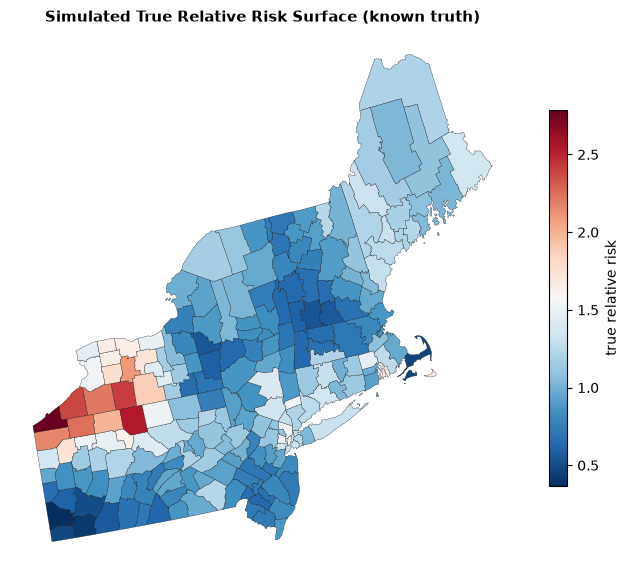

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
counties.assign(theta_true=theta_true).plot(column="theta_true", cmap="RdBu_r", ax=ax,
                                            edgecolor="k", linewidth=0.2, legend=True,
                                            legend_kwds={"label": "true relative risk", "shrink": 0.7})
ax.set_axis_off()
ax.set_title("Simulated True Relative Risk Surface (known truth)")
plt.tight_layout()
plt.show()

With expected counts scaled to average 40, the simulated observed counts genuinely are small — this is the
scenario Chapters 5.5–5.8 use to validate every smoothing method against a true answer only the simulation
knows.

### 4.2 Remedy 2: thinning to emulate a rare outcome

A second, complementary approach starts from the real data and **thins** it — keeping only a small, random
fraction of the actual cases — to emulate what a genuinely rare outcome (rather than diabetes, which is common)
would look like with the same real population and real spatial structure.

In [6]:
rng = np.random.default_rng(1)
thin_fraction = 0.02
O_thinned = rng.binomial(O.astype(int), thin_fraction)
E_thinned = E * thin_fraction
print(f"thinned counts: min={O_thinned.min()}, max={O_thinned.max()}, mean={O_thinned.mean():.2f}")
print(f"counties with 0 cases after thinning: {int((O_thinned == 0).sum())} of {len(O_thinned)}")

thinned counts: min=6, max=4124, mean=380.93
counties with 0 cases after thinning: 0 of 217


Thinning has the advantage of preserving the real (if modest) spatial pattern in `Dia_pct` rather than
substituting an artificial one — but unlike the simulation, there is no known "true" risk to score against, so
it is useful for demonstration but not for the formal validation Chapter 5.8 performs.

***
## 5. A Real-Rate Example: Cancer Incidence

Reusing Part 4, Chapter 4.4's derivation exactly: `cancer_areas.shp` provides only a `rate`; counts are derived
as $\text{rate} \times \text{population} / 100{,}000$, with population summed from `cancer_points.csv` using
the same canonical zero-padded FIPS key needed to avoid the int/float key-mismatch hazard found there.

In [7]:
cancer_areas = gpd.read_file(DATA / "cancer_areas.shp")
cancer_points = pd.read_csv(DATA / "cancer_points.csv")

points_valid = cancer_points.dropna(subset=["FIPS"]).copy()
points_valid["key"] = points_valid["FIPS"].astype(int).astype(str).str.zfill(5)
cancer_areas["key"] = cancer_areas["FIPS"].astype(str).str.zfill(5)
pop_by_key = points_valid.groupby("key")["POP10"].sum()
cancer_areas["pop"] = cancer_areas["key"].map(pop_by_key)
cancer_areas["cases_derived"] = (cancer_areas["rate"] * cancer_areas["pop"] / 100_000).round()

print(f"cancer_areas: {len(cancer_areas)} counties — the same Northeast counties as diabetes_northeast.shp")
print(f"derived cases: min={cancer_areas['cases_derived'].min():.0f}, "
      f"max={cancer_areas['cases_derived'].max():.0f}, "
      f"median={cancer_areas['cases_derived'].median():.0f}")

cancer_areas: 217 counties — the same Northeast counties as diabetes_northeast.shp
derived cases: min=4, max=3184, median=131


The 217 `cancer_areas` counties are the **same** Northeast counties as `diabetes_northeast.shp` (confirmed by
FIPS in Part 4), so the same `w_binary` weights built above apply directly — a convenient real second outcome
variable to smooth in Chapters 5.4–5.9 alongside the diabetes counts, without needing a second weights build.

***
## 6. Spatial Weights for ICAR: Binary, and the Island

The BYM model's ICAR prior (Chapters 5.6–5.7) is defined purely by the **presence** of a neighbour relation —
it needs binary adjacency, not the row-standardised weights used throughout Parts 2–4. This is why every
weights object built in this Part uses `transform="binary"`.

In [8]:
print(w_binary.summary())
island_idx = w_binary.islands()
print(f"\nisland(s): {[counties.iloc[i]['COUNTY'] for i in island_idx]}")

Spatial Weights (W)
  Observations        217
  Transform           binary
  Min neighbors       0
  Mean neighbors      5.189
  Max neighbors       10
  Islands             1
  Components          2
  Nonzero weights     1126

island(s): ['Nantucket County']


The familiar Nantucket island reappears here with a new, Part-5-specific consequence: the built-in Gibbs
sampler (Chapter 5.7) handles it gracefully — an area with no spatial neighbours simply receives **only** the
unstructured (non-spatial) random effect, with no ICAR contribution. **PyMC's ICAR implementation requires a
fully connected graph** and raises an explicit error otherwise; using it means linking the island to its
nearest neighbour first, exactly as Part 2, Chapter 2.2 and Part 3, Chapter 3.6 both did for their own reasons.

In [9]:
wk1 = KNN(counties, k=1)
island_id = w_binary.id_order[island_idx[0]]
nearest_id = wk1.neighbors[island_id][0]
print(f"linking island (id={island_id}, {counties.loc[island_id, 'COUNTY']}) to nearest county "
      f"(id={nearest_id}, {counties.loc[nearest_id, 'COUNTY']})")

neighbors = {i: list(w_binary.neighbors[i]) for i in w_binary.id_order}
neighbors[island_id] = [nearest_id]
neighbors[nearest_id] = neighbors[nearest_id] + [island_id]
w_linked = W(neighbors, ids=w_binary.id_order, transform="binary")
print(f"after linking: islands={len(w_linked.islands())}, components={w_linked.n_components()}")

linking island (id=33, Nantucket County) to nearest county (id=24, Barnstable County)
after linking: islands=0, components=1


`w_binary` (with the island left alone) is used for the built-in sampler throughout this Part; `w_linked` (the
island explicitly connected) is used whenever `backend='pymc'` is needed. Both are legitimate, documented
choices — the difference is a genuine PyMC implementation requirement, not something to paper over silently.

***
## 7. Summary and Conclusions

This chapter built every dataset the rest of Part 5 uses, and surfaced a real complication along the way.

### What we did

1. Computed expected counts by indirect standardisation, and stated its without-age-strata limitation
   explicitly.
2. **Confirmed the real diabetes data is not actually sparse** (minimum 368 observed cases, minimum expected
   count over 300) — too well-measured for smoothing's benefit to be dramatic on its own.
3. Built the primary validation tool: a simulated true risk surface (`simulate_relative_risk`) and simulated
   small counts from it (`simulate_counts`, expected counts averaging 40) — the scenario Chapters 5.5–5.8 use
   to check smoothing methods against a known answer.
4. Built a second, real-data-preserving alternative: thinning observed counts to emulate a rarer outcome.
5. Reproduced Part 4's cancer-incidence derivation exactly, confirming it shares the same 217 counties and
   weights as the diabetes data.
6. Built binary Queen weights (what ICAR needs) and explicitly linked the one island for PyMC's connectivity
   requirement.

### Practical takeaways

- Always check whether real data is actually sparse enough to need smoothing's full machinery before assuming
  it is — Section 4's finding here (it is not) is itself a useful, checkable diagnostic, not an obstacle.
- Simulation with a known truth is the only way to *validate* a smoother, as opposed to merely *applying* one;
  Chapter 5.8 depends entirely on the simulation built here.
- Binary weights and row-standardised weights are not interchangeable — ICAR specifically needs the former,
  and the island needs an explicit, documented decision before PyMC (not the built-in sampler) can run.

### Next steps

**Chapter 5.4 (Raw Estimates and Naïve Inference)** takes these prepared datasets and computes the full raw
picture — SMR, exact confidence intervals, excess p-values — before any smoothing is applied.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Lawson, A. B. (2018). *Bayesian Disease Mapping* (3rd ed.). CRC Press. | Indirect standardisation and its limitations, Chapter 1 |
| Rothman, K. J., Greenland, S. & Lash, T. L. (2008). *Modern Epidemiology* (3rd ed.). Lippincott Williams & Wilkins. | Standard reference on standardisation methods, including age adjustment |

### Key papers

| Paper | Contribution |
|---|---|
| Besag, J., York, J. & Mollié, A. (1991). Bayesian image restoration, with two applications in spatial statistics. *Annals of the Institute of Statistical Mathematics*, 43, 1–20. | The ICAR structure this chapter's binary weights feed into |

### In this library

| Object | Role |
|---|---|
| `spatialstats.bayes.expected_counts` | Indirect standardisation |
| `spatialstats.bayes.simulate_relative_risk`, `simulate_counts` | Known-truth simulation, used throughout Chapters 5.5–5.8 |
| `spatialstats.weights.Queen(transform="binary")` | ICAR-compatible adjacency |
| Chapter 5.6–5.7 | Where `w_binary` and `w_linked`, built here, are actually used |